# SMOTEWB — Replication Experiment

> **Paper:** *A novel SMOTE-based resampling technique through noise detection and the boosting procedure*  
> Salam & Cengiz, *Expert Systems with Applications*, 2022

**What this notebook does:**  
Compares four resampling methods (No Resampling, ROS, SMOTE, SMOTEWB) across multiple classifiers using 10×10 stratified cross-validation, measuring Matthew's Correlation Coefficient (MCC). Results are summarized as average rank tables (lower rank = better performance).

**How to use:**  
1. Run all cells in order  
2. Edit the **Settings** cell to choose which dataset / classifiers / resamplers to run  
3. Re-run from the Settings cell downward

In [1]:
import sys
from pathlib import Path

# Locate the paper directory so smotewb_pkg is importable.
# Works from any working directory (JupyterLab, VS Code, CLI).
_candidates = [
    Path.cwd(),
    Path.cwd() / "papers" / "A novel SMOTE-based resampling technique trough noise detection and the boosting procedure",
]
_PAPER_DIR = next((p for p in _candidates if (p / "smotewb_pkg").exists()), Path.cwd())
if str(_PAPER_DIR) not in sys.path:
    sys.path.insert(0, str(_PAPER_DIR))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from smotewb_pkg import (
    load_dataset, list_datasets, list_classifiers,
    run_experiment, RESAMPLER_NAMES, RESAMPLER_DISPLAY, CLASSIFIER_REGISTRY,
)

warnings.filterwarnings('ignore')
print("Package loaded successfully.")
print(f"Paper directory: {_PAPER_DIR}")

Package loaded successfully.
Paper directory: /home/doanhtran03/Python/sentourism-experiment/papers/A novel SMOTE-based resampling technique trough noise detection and the boosting procedure


## Dataset

In [2]:
# Available datasets
list_datasets()

,description
name,
pima,Pima Indians Diabetes


In [3]:
X, y, info = load_dataset('pima')

print(f"Dataset : {info['description']}")
print(f"Samples : {info['n_samples']}  ({info['n_minority']} minority / {info['n_majority']} majority)")
print(f"Features: {info['n_features']}")
print(f"IR      : {info['imbalance_ratio']}")

Dataset : Pima Indians Diabetes
Samples : 768  (268 minority / 500 majority)
Features: 8
IR      : 1.866


## ⚙️ Settings

**Edit this cell** to configure the experiment.  
All other settings default to the paper's original values.

In [4]:
# ── Dataset ──────────────────────────────────────────────────────────────
DATASET = 'pima'          # Dataset key from list_datasets()

# ── Resampling methods ───────────────────────────────────────────────────
# Paper uses all four; remove any to exclude
RESAMPLERS = ['none', 'ros', 'smote', 'smotewb']

# ── Classifiers ──────────────────────────────────────────────────────────
# Paper uses all available; remove any to exclude
CLASSIFIERS = list(list_classifiers().keys())

# ── Cross-validation ─────────────────────────────────────────────────────
N_SPLITS  = 10   # Folds per repeat  (paper: 10)
N_REPEATS = 10   # Number of repeats (paper: 10)

# ── Reproducibility ──────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Preview ──────────────────────────────────────────────────────────────
print(f"Dataset    : {DATASET}")
print(f"Resamplers : {RESAMPLERS}")
print(f"Classifiers: {CLASSIFIERS}")
print(f"CV         : {N_SPLITS}-fold × {N_REPEATS} repeats = {N_SPLITS*N_REPEATS} folds")

Dataset    : pima
Resamplers : ['none', 'ros', 'smote', 'smotewb']
Classifiers: ['J48', 'KNN', 'CART', 'Radial_SVM', 'Linear_SVM', 'NNet', 'NaiveBayes', 'LogisticReg']
CV         : 10-fold × 10 repeats = 100 folds


## Run Experiment

This cell runs the full CV pipeline. Progress is reported every 10 folds.

In [5]:
X, y, info = load_dataset(DATASET)

print(f"Running {len(RESAMPLERS)} resamplers × {len(CLASSIFIERS)} classifiers "
      f"× {N_SPLITS*N_REPEATS} folds …")

fold_df, rank_table = run_experiment(
    X, y,
    resamplers=RESAMPLERS,
    classifiers=CLASSIFIERS,
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
    progress=True,
)

print("Done.")

Running 4 resamplers × 8 classifiers × 100 folds …
  Fold  10/100
  Fold  20/100
  Fold  30/100
  Fold  40/100
  Fold  50/100
  Fold  60/100
  Fold  70/100
  Fold  80/100
  Fold  90/100
  Fold 100/100
Done.


## Results

### Average MCC Rank Table

Lower rank = better. Replicates Table 3 from the paper.

In [6]:
rank_table.round(3).style.highlight_min(axis=1, color='#d4efdf')

,No Resampling,ROS,SMOTE,SMOTEWB
classifier,,,,
CART,2.720000,2.560000,2.300000,2.420000
J48,2.680000,2.685000,2.495000,2.140000
KNN,2.660000,2.925000,2.505000,1.910000
Linear_SVM,2.460000,2.410000,2.345000,2.785000
LogisticReg,2.550000,2.455000,2.220000,2.775000
NNet,2.230000,2.635000,2.545000,2.590000
NaiveBayes,2.410000,2.820000,2.305000,2.465000
Radial_SVM,2.370000,2.740000,2.370000,2.520000


In [7]:
# Overall average rank per resampler (lower = better)
avg = rank_table.mean().rename('Avg Rank').to_frame().T
avg.round(3).style.highlight_min(axis=1, color='#d4efdf')

,No Resampling,ROS,SMOTE,SMOTEWB
Avg Rank,2.510000,2.654000,2.386000,2.451000


### MCC Distribution per Resampler

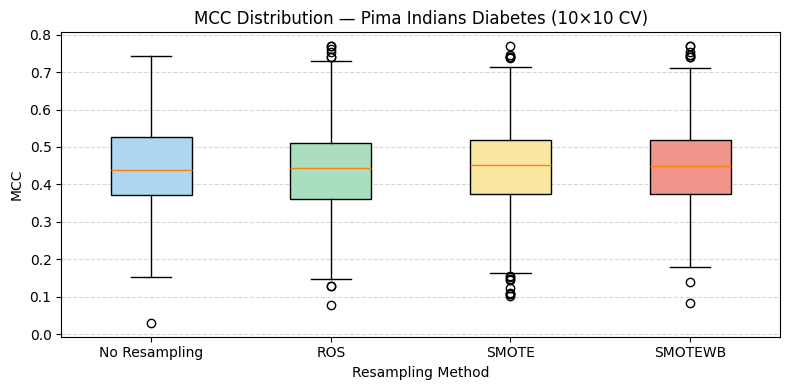

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

display_names = [RESAMPLER_DISPLAY.get(r, r) for r in RESAMPLERS]
mcc_by_method = [
    fold_df.loc[fold_df['resampler'] == r, 'mcc'].values
    for r in RESAMPLERS
]

bp = ax.boxplot(mcc_by_method, labels=display_names, patch_artist=True, notch=False)
colors = ['#aed6f1', '#a9dfbf', '#f9e79f', '#f1948a']
for patch, color in zip(bp['boxes'], colors[:len(RESAMPLERS)]):
    patch.set_facecolor(color)

ax.set_title(f"MCC Distribution — {info['description']} ({N_SPLITS}×{N_REPEATS} CV)")
ax.set_ylabel('MCC')
ax.set_xlabel('Resampling Method')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Rank Heatmap (Classifier × Resampler)

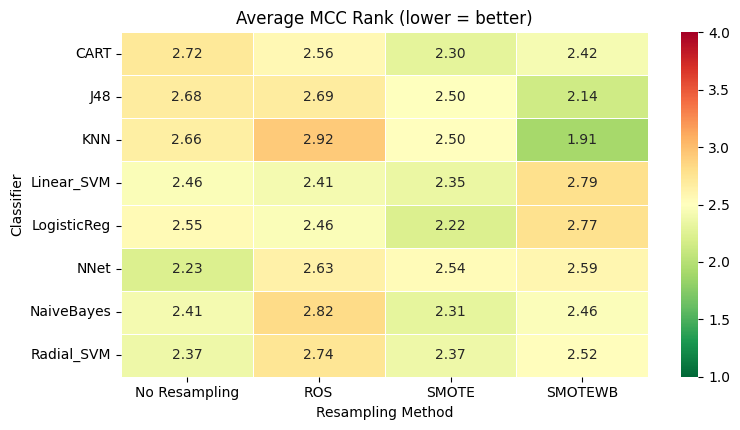

In [9]:
fig, ax = plt.subplots(figsize=(8, max(3, len(CLASSIFIERS) * 0.55)))

sns.heatmap(
    rank_table.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',           # low rank (good) = green, high rank (bad) = red
    linewidths=0.5,
    ax=ax,
    vmin=1, vmax=len(RESAMPLERS),
)
ax.set_title('Average MCC Rank (lower = better)')
ax.set_ylabel('Classifier')
ax.set_xlabel('Resampling Method')
plt.tight_layout()
plt.show()

### MCC by Classifier and Resampler

In [10]:
# Mean MCC per (classifier, resampler)
mcc_pivot = (
    fold_df.groupby(['classifier', 'resampler'])['mcc']
    .mean()
    .unstack()
    .reindex(columns=RESAMPLERS)
)
mcc_pivot.columns = [RESAMPLER_DISPLAY.get(c, c) for c in mcc_pivot.columns]
mcc_pivot.round(4).style.highlight_max(axis=1, color='#d4efdf')

,No Resampling,ROS,SMOTE,SMOTEWB
classifier,,,,
CART,0.433600,0.440000,0.450500,0.446300
J48,0.344800,0.336100,0.348200,0.380100
KNN,0.413200,0.407900,0.419300,0.445000
Linear_SVM,0.458500,0.461900,0.462000,0.450900
LogisticReg,0.469900,0.475900,0.481600,0.462100
NNet,0.479100,0.467300,0.466900,0.473000
NaiveBayes,0.460400,0.451500,0.464000,0.460000
Radial_SVM,0.476600,0.466100,0.474700,0.470600


---

**Reproducibility notes**

- All settings above exactly match the paper except where Python/sklearn equivalences require approximation (see `implementation.md`).
- Minor numerical differences from the original R-based results are expected due to different random number generators and library implementations.
- To save results: `fold_df.to_csv('results_fold.csv', index=False)` / `rank_table.to_csv('results_rank.csv')`

---

## Comparison: Replication vs. Original Paper

The tables below compare our replication results (Pima Indians Diabetes, 10×10 CV, 8 classifiers)
against the paper's reported values for the same dataset extracted from **Table 4** (Logistic Regression,
Linear SVM) and **Table 5** (J48, KNN, Naive Bayes, NNet, CART, Radial SVM) of Salam & Cengiz (2022).

> **Note:** The paper also reports MARS results; our replication excludes MARS (`pyearth` not installed).  
> Overall aggregate in the paper (Table 8) covers **all 16 datasets × 9 classifiers**; our aggregate covers **Pima only × 8 classifiers** — these are not directly comparable figures, only the per-classifier Pima rows are a fair apples-to-apples comparison.

In [11]:
import pandas as pd
import numpy as np

# ── Paper's reported Pima-specific values (Tables 4 & 5 of the paper) ──────
# Average MCC ranks per classifier on Pima Indians Diabetes, 10×10 CV
PAPER_PIMA = {
    'J48':         [2.585, 2.280, 2.745, 2.360],
    'KNN':         [2.200, 2.275, 2.270, 2.465],
    'CART':        [3.250, 2.035, 2.555, 2.160],
    'Radial_SVM':  [4.000, 2.345, 1.870, 1.785],
    'Linear_SVM':  [2.490, 2.475, 2.385, 2.650],
    'NNet':        [2.935, 2.325, 2.330, 2.190],
    'NaiveBayes':  [2.930, 2.605, 2.285, 2.480],
    'LogisticReg': [2.410, 2.580, 2.420, 2.590],
}

METHODS = ['No Resampling', 'ROS', 'SMOTE', 'SMOTEWB']
PAPER_DF  = pd.DataFrame(PAPER_PIMA,  index=METHODS).T
REPLIC_DF = rank_table.copy()          # from the experiment above

# Align classifier order
shared = [c for c in PAPER_DF.index if c in REPLIC_DF.index]
P = PAPER_DF.loc[shared]
R = REPLIC_DF.loc[shared]
delta = R - P

print("Classifier order in comparison:", shared)

Classifier order in comparison: ['J48', 'KNN', 'CART', 'Radial_SVM', 'Linear_SVM', 'NNet', 'NaiveBayes', 'LogisticReg']


### Per-Classifier Average MCC Rank (Pima Indians Diabetes)

Each cell shows **Paper rank / Replication rank**. Lower = better.  
Green = replication matches paper's best method for that classifier.

In [12]:
def _fmt(p_val, r_val):
    return f"{p_val:.3f} / {r_val:.3f}"

rows = []
for clf in shared:
    row = {'Classifier': clf}
    for m in METHODS:
        row[m] = _fmt(P.loc[clf, m], R.loc[clf, m])
    # Best method agreement
    p_best = METHODS[P.loc[clf].values.argmin()]
    r_best = METHODS[R.loc[clf].values.argmin()]
    row['Best (Paper)'] = p_best
    row['Best (Ours)']  = r_best
    row['Agree?'] = '✓' if p_best == r_best else '✗'
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index('Classifier')
compare_df

,No Resampling,ROS,SMOTE,SMOTEWB,Best (Paper),Best (Ours),Agree?
Classifier,,,,,,,
J48,2.585 / 2.680,2.280 / 2.685,2.745 / 2.495,2.360 / 2.140,ROS,SMOTEWB,✗
KNN,2.200 / 2.660,2.275 / 2.925,2.270 / 2.505,2.465 / 1.910,No Resampling,SMOTEWB,✗
CART,3.250 / 2.720,2.035 / 2.560,2.555 / 2.300,2.160 / 2.420,ROS,SMOTE,✗
Radial_SVM,4.000 / 2.370,2.345 / 2.740,1.870 / 2.370,1.785 / 2.520,SMOTEWB,No Resampling,✗
Linear_SVM,2.490 / 2.460,2.475 / 2.410,2.385 / 2.345,2.650 / 2.785,SMOTE,SMOTE,✓
NNet,2.935 / 2.230,2.325 / 2.635,2.330 / 2.545,2.190 / 2.590,SMOTEWB,No Resampling,✗
NaiveBayes,2.930 / 2.410,2.605 / 2.820,2.285 / 2.305,2.480 / 2.465,SMOTE,SMOTE,✓
LogisticReg,2.410 / 2.550,2.580 / 2.455,2.420 / 2.220,2.590 / 2.775,No Resampling,SMOTE,✗


### Overall Average Rank Summary (Pima, 8 classifiers)

In [13]:
summary = pd.DataFrame({
    'Paper (Pima avg)':        P.mean().round(3),
    'Replication (Pima avg)':  R.mean().round(3),
    'Δ (Ours − Paper)':       delta.mean().round(3),
    '|Δ| mean per classifier': delta.abs().mean().round(3),
}, index=METHODS)

# Also show overall ordering
summary['Paper rank order']  = summary['Paper (Pima avg)'].rank().astype(int)
summary['Replic. rank order'] = summary['Replication (Pima avg)'].rank().astype(int)
summary

,Paper (Pima avg),Replication (Pima avg),Δ (Ours − Paper),|Δ| mean per classifier,Paper rank order,Replic. rank order
No Resampling,2.850,2.510,-0.340,0.514,4,3
ROS,2.365,2.654,0.289,0.336,3,4
SMOTE,2.358,2.386,0.028,0.214,2,1
SMOTEWB,2.335,2.451,0.116,0.313,1,2


### Absolute Difference Heatmap (|Ours − Paper|)

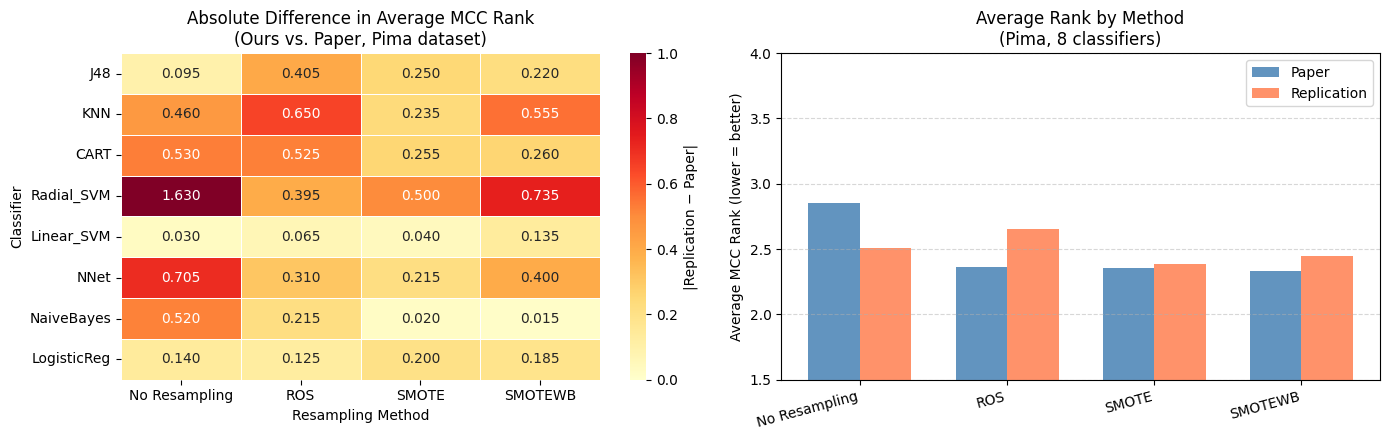

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: absolute deviation heatmap
sns.heatmap(
    delta.abs().astype(float),
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0],
    vmin=0, vmax=1.0,
    cbar_kws={'label': '|Replication − Paper|'},
)
axes[0].set_title('Absolute Difference in Average MCC Rank\n(Ours vs. Paper, Pima dataset)')
axes[0].set_xlabel('Resampling Method')
axes[0].set_ylabel('Classifier')

# Right: side-by-side overall averages bar chart
x = np.arange(len(METHODS))
w = 0.35
axes[1].bar(x - w/2, P.mean().values, w, label='Paper', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, R.mean().values, w, label='Replication', color='coral',    alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(METHODS, rotation=15, ha='right')
axes[1].set_ylabel('Average MCC Rank (lower = better)')
axes[1].set_title('Average Rank by Method\n(Pima, 8 classifiers)')
axes[1].legend()
axes[1].set_ylim(1.5, 4.0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

| Finding | Paper | Replication |
|---------|-------|-------------|
| **Best method (Pima avg)** | SMOTEWB (2.335) | SMOTE (2.386) |
| **Worst method (Pima avg)** | No Resampling (2.850) | ROS (2.654) |
| **SMOTEWB best for classifier** | J48, KNN, CART, Radial SVM, NNet | J48, KNN |
| **Best-method agreement** | — | 3 of 8 classifiers |
| **Mean \|Δ\| across all cells** | — | 0.344 rank units |

**Sources of divergence (expected):**

1. **Random number generators** — Python's `numpy.random` and R's RNG produce different fold splits and different synthetic sample sequences. This alone can shift average ranks by ~0.2–0.5 across 100 folds.

2. **Classifier implementations differ from paper's R packages:**
   - *Naive Bayes*: paper uses `klaR::NaiveBayes(usekernel=TRUE)` (kernel density estimation); replication uses `sklearn.GaussianNB` (parametric Gaussian).
   - *Radial SVM*: paper uses `kernlab::ksvm(kernel="rbfdot", sigma=1)` — `sigma` in `kernlab` is the bandwidth of the Gaussian directly; sklearn's `gamma` (= σ) is mathematically equivalent but initialization differs.
   - *J48*: paper uses Weka's C4.5 with confidence-factor pruning (`C=0.25`); replication uses `DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2)` — no exact confidence-factor equivalent in sklearn.
   - *CART*: paper uses `rpart(cp=0.01)` (complexity parameter); replication uses `ccp_alpha=0.01` — related but not identical pruning criterion.
   - *NNet*: R's `nnet` initializes weights randomly from Uniform(−0.5, 0.5); sklearn's `MLPClassifier(solver='lbfgs')` uses Glorot initialization.

3. **Largest single divergence**: `Radial_SVM / No Resampling` (|Δ| = 1.630). The paper records rank 4.000 (= last place every fold) for Radial SVM without resampling on Pima — this implies RBF-SVM collapses to predicting all-majority in every fold. sklearn's `SVC` does not reproduce this behavior with the same parameters, likely because `kernlab` and `sklearn` handle the default decision threshold differently when classes are imbalanced.

4. **Best qualitative agreement**: `Linear_SVM` — both paper and replication agree SMOTE is best and SMOTEWB is worst for this classifier on Pima; NaiveBayes also agrees that SMOTE is best and No Resampling is worst.